In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv("data/cleaned/cleaned_border_crossing.csv")

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(49993, 10)


,port_name,state,port_code,border,date,measure,value,latitude,longitude,point
0,Richford,Vermont,203,US-Canada Border,2026-01-01,Personal Vehicles,4050,45.011740,-72.588559,POINT (-72.588559 45.01174)
1,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Trucks,208,31.334084,-109.948413,POINT (-109.948413 31.334084)
2,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Truck Containers Empty,103,31.334084,-109.948413,POINT (-109.948413 31.334084)
3,Sumas,Washington,3009,US-Canada Border,2026-01-01,Rail Containers Empty,338,49.002388,-122.264805,POINT (-122.264805 49.002388)
4,Vanceboro,Maine,105,US-Canada Border,2026-01-01,Rail Containers Loaded,5908,45.568761,-67.428541,POINT (-67.428541 45.568761)


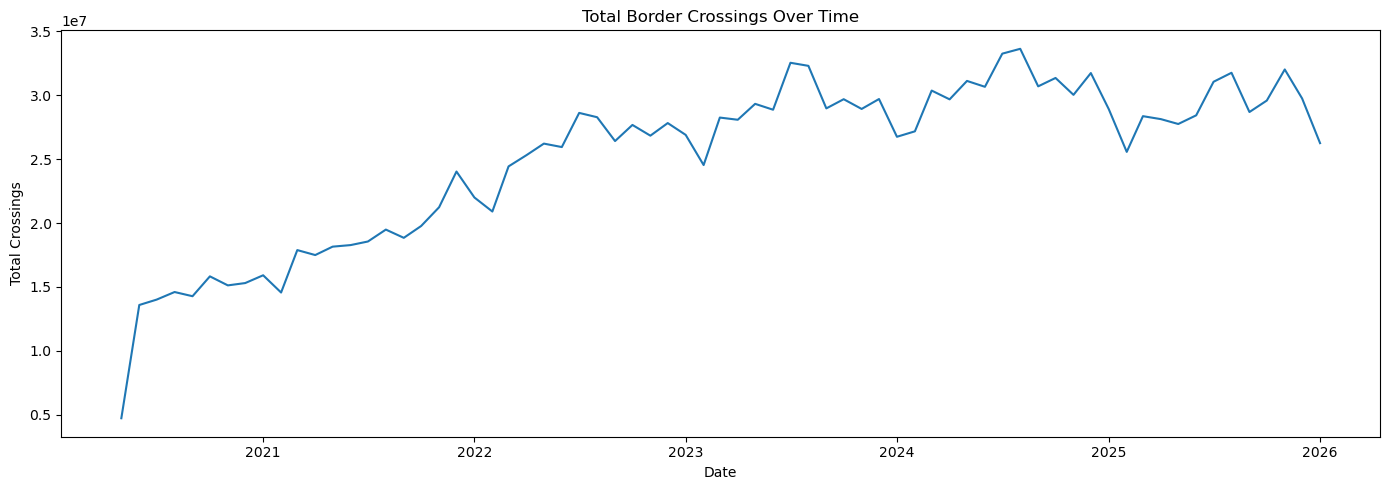

In [5]:
# Total crossings by date
df_time = df.groupby("date")["value"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(df_time["date"], df_time["value"])
plt.title("Total Border Crossings Over Time")
plt.xlabel("Date")
plt.ylabel("Total Crossings")
plt.tight_layout()
plt.show()

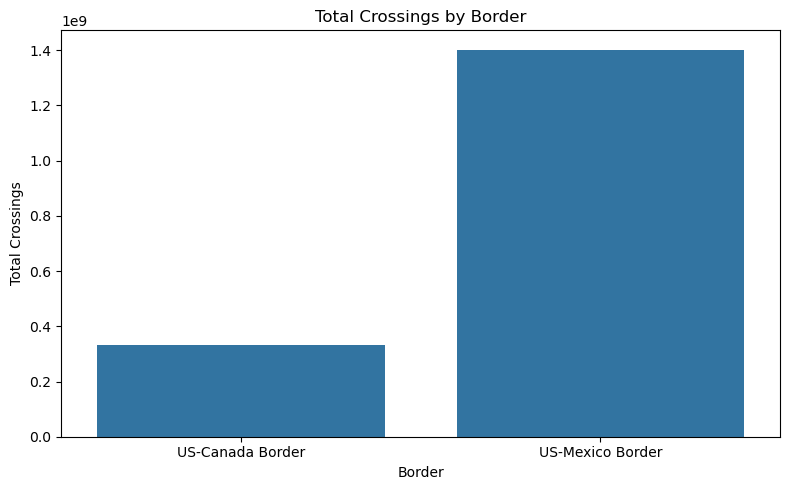

In [6]:
df_border = df.groupby("border")["value"].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=df_border, x="border", y="value")
plt.title("Total Crossings by Border")
plt.xlabel("Border")
plt.ylabel("Total Crossings")
plt.tight_layout()
plt.show()

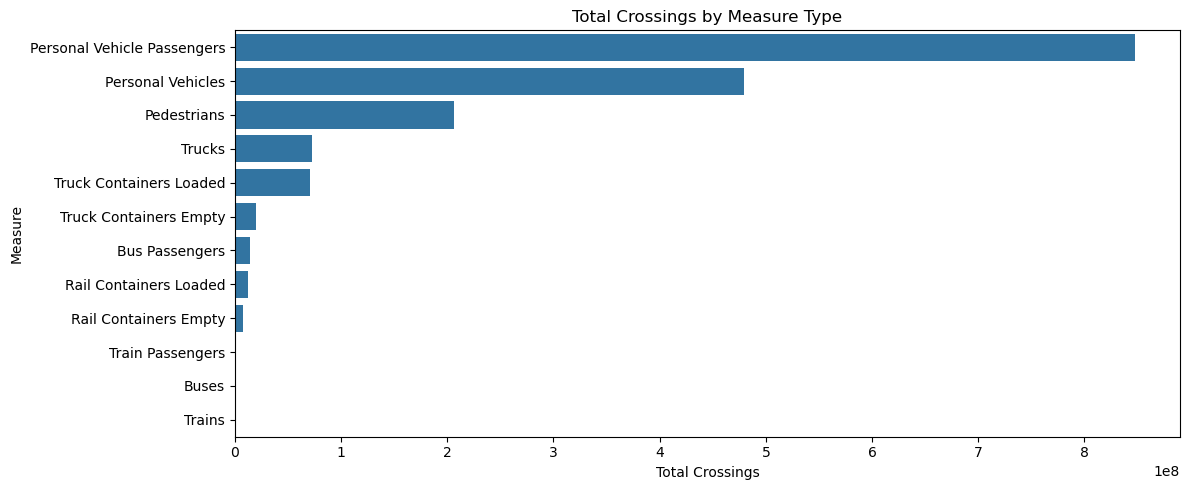

In [7]:
df_measure = df.groupby("measure")["value"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_measure, x="value", y="measure")
plt.title("Total Crossings by Measure Type")
plt.xlabel("Total Crossings")
plt.ylabel("Measure")
plt.tight_layout()
plt.show()

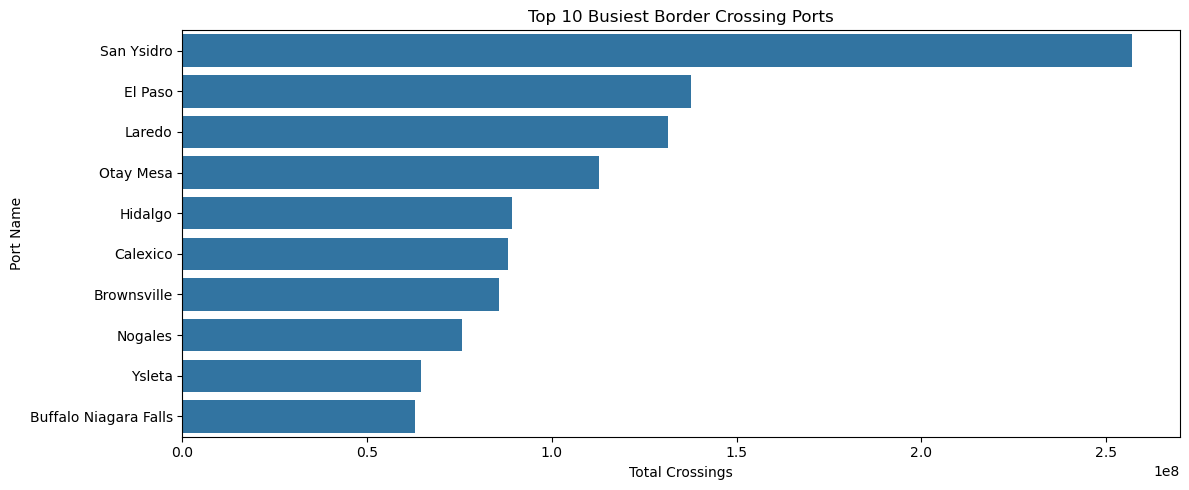

In [8]:
df_ports = df.groupby("port_name")["value"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_ports, x="value", y="port_name")
plt.title("Top 10 Busiest Border Crossing Ports")
plt.xlabel("Total Crossings")
plt.ylabel("Port Name")
plt.tight_layout()
plt.show()

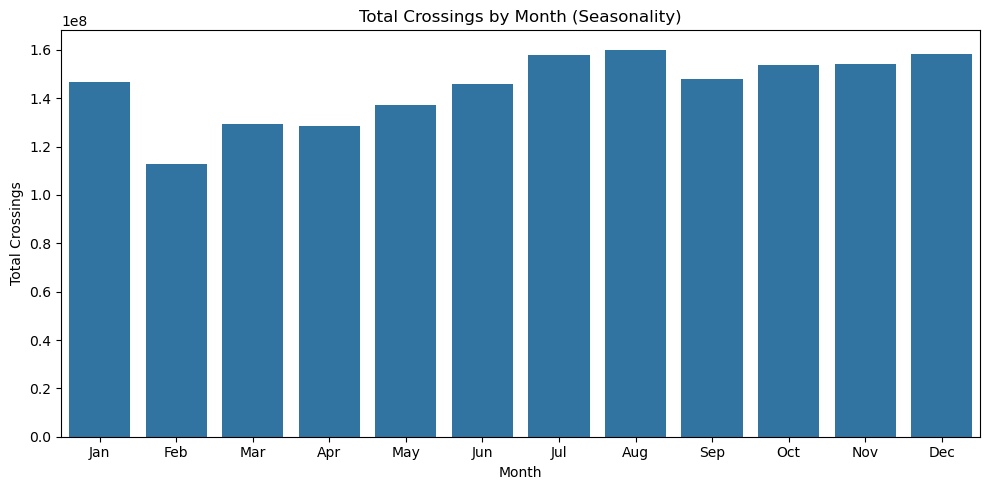

In [9]:
df["month"] = df["date"].dt.month

df_month = df.groupby("month")["value"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_month, x="month", y="value")
plt.title("Total Crossings by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Total Crossings")
plt.xticks(ticks=range(12), labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()